In [1]:
from quadcoil import SurfaceRZFourierJAX
from surface_transport import SurfaceHarmonicJAX, SurfaceShearJAX
from functools import partial
from jax import jit
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

def plot_gamma(gamma, close=True, ax=None, **kwargs):
    """Plot ``surf.gamma()`` of a ``SurfaceJAX`` as a 3D surface, equal aspect."""
    gamma
    if close:
        # quadpoints are open grids in [0, 1); wrap once in theta (and in phi
        # only if the phi grid spans the whole torus) so the mesh has no seam.
        gamma = np.concatenate([gamma, gamma[:, :1]], axis=1)
        if np.isclose(float(surf.quadpoints_phi[-1] + surf.dphi), 1.0):
            gamma = np.concatenate([gamma, gamma[:1]], axis=0)

    if ax is None:
        ax = plt.figure(figsize=(7, 6)).add_subplot(projection='3d')
    x, y, z = gamma[..., 0], gamma[..., 1], gamma[..., 2]
    ax.plot_surface(
        x, y, z,
        **{'rstride': 1, 'cstride': 1, 'linewidth': 0,
           'antialiased': False, 'cmap': 'viridis', **kwargs},
    )
    ax.set_aspect('equal')  # matplotlib >= 3.6
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    return ax

In [2]:
nfp = 3
stellsym = True
n_phi = 32
n_theta = 33
major_radius = 8
minor_radius = 2
quadpoints_phi = jnp.linspace(0, 1/nfp, 33)
quadpoints_theta = jnp.linspace(0, 1, 32)

In [3]:
dofs = np.random.rand(4)/100

In [4]:
dofs

array([0.00200801, 0.00616657, 0.00780888, 0.00650814])

In [5]:
surf = SurfaceHarmonicJAX(
    nfp=nfp,
    stellsym=stellsym,
    seed_major_radius=major_radius,
    seed_minor_radius=minor_radius,
    quadpoints_phi=quadpoints_phi,
    quadpoints_theta=quadpoints_theta,
    step_num=20,
    a_max=1,
    l_max=3,
    # modes: (1,0),(2,0),(3,0),(3,1) with m=0 always included
    dofs=dofs,
    # backend='recursion',
    # gamma_scale=None,
    irregular=True
)

In [6]:
surf.gamma()

Array([[[ 9.9760343 ,  0.        , -0.02263071],
        [ 9.93990111,  0.        ,  0.37984598],
        [ 9.82273074,  0.        ,  0.76582392],
        ...,
        [ 9.80075593,  0.        , -0.81077368],
        [ 9.92921082,  0.        , -0.42502893],
        [ 9.9760343 ,  0.        , -0.02263071]],

       [[ 9.956223  ,  0.64466577, -0.02262601],
        [ 9.9201847 ,  0.64219189,  0.37992486],
        [ 9.80332447,  0.63417488,  0.76598173],
        ...,
        [ 9.78140796,  0.63271248, -0.81092185],
        [ 9.90952247,  0.64148121, -0.42509833],
        [ 9.956223  ,  0.64466577, -0.02262601]],

       [[ 9.89676873,  1.28734271, -0.02261208],
        [ 9.86101345,  1.28241481,  0.38015835],
        [ 9.74507809,  1.2664461 ,  0.76644888],
        ...,
        [ 9.72333548,  1.26353252, -0.81136048],
        [ 9.85043492,  1.28099878, -0.42530379],
        [ 9.89676873,  1.28734271, -0.02261208]],

       ...,

       [[-3.83351288,  9.21452449, -0.02261208],
        [-3

<Axes3D: xlabel='x', ylabel='y', zlabel='z'>

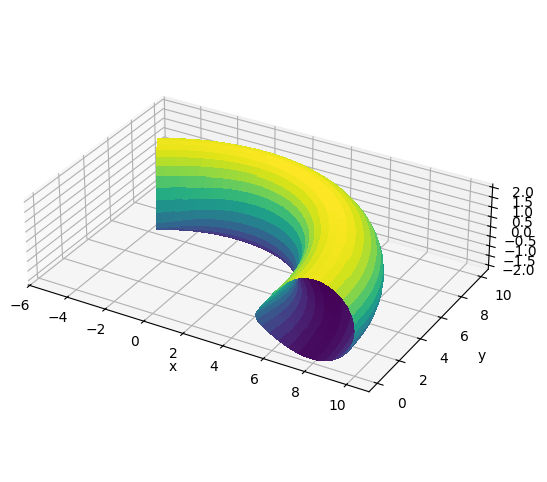

In [7]:
plot_gamma(surf.gamma())

num_modes: 25


<Axes3D: xlabel='x', ylabel='y', zlabel='z'>

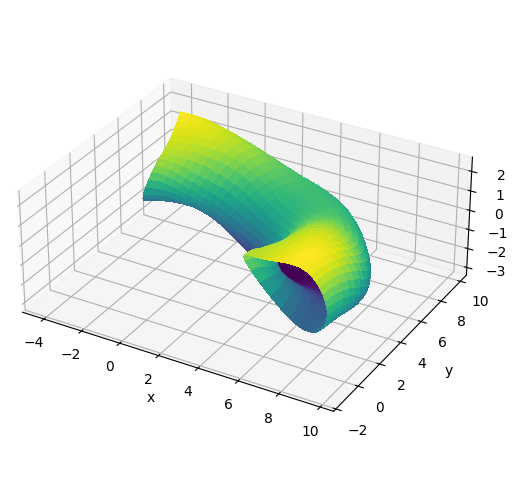

In [39]:
# n_steps=5 cylindrical shear: A B C A B
m_shear = ((2, 2), (1, 1), (2, 2), (1, 1), (1, 1))
surf_shear = SurfaceShearJAX(
    nfp=nfp,
    stellsym=stellsym,
    seed_major_radius=major_radius,
    seed_minor_radius=minor_radius,
    quadpoints_phi=quadpoints_phi,
    quadpoints_theta=quadpoints_theta,
    m_shear=m_shear,
)
# Random dofs; only g (B-stage, kind==1) coefficients are /1000
dofs_shear = np.random.rand(surf_shear.num_modes) * 2
for kind, _, _, off, size in surf_shear._plan:
    if kind == 1:
        dofs_shear[off:off + size] /= 100
surf_shear = SurfaceShearJAX(
    nfp=nfp,
    stellsym=stellsym,
    seed_major_radius=major_radius,
    seed_minor_radius=minor_radius,
    quadpoints_phi=quadpoints_phi,
    quadpoints_theta=quadpoints_theta,
    m_shear=m_shear,
    dofs=dofs_shear,
)
print('num_modes:', surf_shear.num_modes)
plot_gamma(surf_shear.gamma())


In [32]:
len(dofs_shear)

25

In [15]:
seed_surf.to_simsopt().plot()

NameError: name 'seed_surf' is not defined

In [28]:
@partial(jit, static_argnames=('L'))
def solid_harmonics_np(x, y, z, L):
    """Real regular solid harmonics R_l^m, Racah normalised.
    Returns dict (l, m) -> array;  m > 0 cosine-type, m < 0 sine-type."""
    r2 = x*x + y*y + z*z
    out = {}
    out[(0, 0)] = np.ones_like(x)
    for l in range(1, L+1):
        # diagonal step: (l-1,l-1) -> (l,l)
        c = np.sqrt((2*l-1)/(2*l)) * (np.sqrt(2.0) if l == 1 else 1.0)
        Cp = out[(l-1, l-1)]
        Sp = out[(l-1, -(l-1))] if l > 1 else np.zeros_like(x)
        out[(l,  l)] = c*(x*Cp - y*Sp)
        out[(l, -l)] = c*(y*Cp + x*Sp)
        # vertical step at fixed m
        for m in range(0, l):
            for sgn in ([1] if m == 0 else [1, -1]):
                mm = sgn*m
                a = (2*l-1)/np.sqrt(l*l - m*m)
                t = a*z*out[(l-1, mm)]
                if l-1 > m:
                    b = np.sqrt((l-1)**2 - m*m)/np.sqrt(l*l - m*m)
                    t = t - b*r2*out[(l-2, mm)]
                out[(l, mm)] = t
    return out


In [29]:
solid_harmonics_np(1, 2, 1, 3)

TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape int64[]
The error occurred while tracing the function solid_harmonics_np at /tmp/ipykernel_1957528/3960604844.py:1 for jit. This concrete value was not available in Python because it depends on the value of the argument x.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerArrayConversionError